# Plotting MARLi Data
Download CAESAR MARLi data [here](https://data.eol.ucar.edu/dataset/list?project=638&children=project). </p>
Spring 2026
***

In [1]:
# pip install packages, if necessary
!pip install xarray netcdf4

In [2]:
!pip install colorcet

In [25]:
# import modules and packages
## XARRAY & NETCDF4 ##
import xarray as xr
from xarray.backends.api import open_datatree
from netCDF4 import Dataset
## MATPLOTLIB ##
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap
## CARTOPY ##
import cartopy.crs as ccrs
## MISC ##
import numpy as np
import os
from PIL import Image, ImageEnhance
import scipy.stats as scipy
import pandas as pd
import colorcet as cc # https://colorcet.holoviz.org/user_guide/index.html

# save figure or no?
savefig = True
savepath = '/home/jovyan/Desktop/Figures/'
if os.path.exists(savepath): # make sure your savepath exists
    print('The savepath exists.')
else:
    print('Invalid savepath.')

# open dataset using netcdf4 
MARLi = Dataset("/home/jovyan/Desktop/CAESAR/CAESAR-MARLi_C130_20240305_R0.cdf")

# set date, plot, and save info based on research flight of interest
rfs = {
    'RF07': ('2024-03-16', '07'),
    'RF04': ('2024-03-05', '04'),
}
choice = 'RF04'
info = rfs.get(choice, 'Not in dictionary. Please check your choice variable and try again.')
date, rf = info[0], info[1]

The savepath exists.


In [26]:
# use xarray for ease of viewing file data (e.g., variables, attributes, etc.)
var = xr.open_dataset("/home/jovyan/Desktop/CAESAR/CAESAR-MARLi_C130_20240305_R0.cdf")
var

<xarray.Dataset> Size: 271MB
Dimensions:             (Time: 16396, layers: 1031)
Dimensions without coordinates: Time, layers
Data variables: (12/15)
    ProductionDateTime  |S24 24B ...
    VersionID           |S1 1B ...
    Lon                 (Time) float32 66kB ...
    Lat                 (Time) float32 66kB ...
    Alt                 (Time) float32 66kB ...
    Pitch               (Time) float32 66kB ...
    ...                  ...
    H                   (layers) float32 4kB ...
    time                (Time) float32 66kB ...
    LSR                 (Time, layers) float32 68MB ...
    Dep                 (Time, layers) float32 68MB ...
    WVMR                (Time, layers) float32 68MB ...
    T                   (Time, layers) float32 68MB ...
Attributes:
    global_att:    This file is generated with MARLi measurements duringSAESAR
    global_att1:   The data for each flight is mapped to the same height bin ...
    global_att2:   For low-level flight, high horizontal data are provided fo...
    global_att3:   Further averaging for WV and T is needed to reduce the noi...
    global_att4:   Observations within 150 m of the aircraft are very sensiti...
    global_att5:  For Question about this product or special processing to su...
    global_att6:   Stony Brook University at zhien.wang@stonybrook.edu

In [27]:
# set the time and fix it to read nicely in the final figure
time = MARLi.variables["time"][:]
time_dt = pd.to_datetime(date) + pd.to_timedelta(time, unit="h")
# extract variables
alt = MARLi.variables["Alt"][:]  # dimensions: (Time,); units = km
height = MARLi.variables["H"][:] # dimensions: (layers,); units = km
lsr = MARLi.variables["LSR"][:]  # dimensions: (Time, layers); units = unitless
dep = MARLi.variables['Dep'][:]  # dimensions: (Time, layers); units = %
wvmr = MARLi.variables['WVMR'][:] # dimensions: (Time, layers); units = g/kg
T = MARLi.variables['T'][:] # dimensions: (Time, layers); units = degree C

In [28]:
# remove invalid data 
mask_dep = (dep > 200) | (dep <= 0)
mask_lsr = (lsr > 100) | (lsr <= 0.9)
mask_T = (T >= 1000) | (T < -100)
mask_wvmr = (wvmr < -0.5) | (wvmr > 100)

# apply mask accordingly
dep_masked = np.ma.masked_array(dep, mask_dep).T
lsr_masked = np.ma.masked_array(lsr, mask_lsr).T
T_masked = np.ma.masked_array(T, mask_T).T
wvmr_masked = np.ma.masked_array(wvmr, mask_wvmr).T

In [29]:
np.max(dep_masked)

100.58954

In [30]:
# set variable of interest
MARLi_vars = {
    'LSR': (lsr_masked, 'Lidar Scattering Ratio', 'jet', 0.8, 2.1, 0.01, 'Lidar Scattering Ratio', 'red'), # 0.8 to 2.1 at 0.01 (full flight profile)
    'Dep': (dep_masked, 'Lidar Linear Depolarization Ratio (%)', 'magma', 0, 20, 0.1, 'Depolarization Ratio', 'red'), #4.1, 
    'WVMR': (wvmr_masked, 'Water Vapor Mixing Ratio (g kg$^{-1}$)', 'bgy', 0, 5, 0.1, 'Water Vapor Mixing Ratio', 'red'),
    'T': (T_masked, 'Atmospheric Temperature ($^{o}$C)', 'bwr', -25, 6, 0.5, 'Atmospheric Temperature', 'darkorchid')
}
var_choice = 'Dep'
info_var = MARLi_vars.get(var_choice, 'Invalid. Check dictionary values and your choice. Try again.')
voi, cbar_label, cmap_choice, vmin, vmax, interval, title, planecolor = info_var[0], info_var[1], info_var[2], info_var[3], info_var[4], info_var[5], info_var[6], info_var[7]

In [31]:
# search for the times you want (xmin, xmax)
timemask_start = (time_dt >= "2024-03-05 07:55:00") & (time_dt < "2024-03-05 07:55:30")
timemask_end = (time_dt >= "2024-03-05 08:10:00") & (time_dt < "2024-03-05 08:10:05")
timemask = timemask_end
indices = np.where(timemask)[0]
indices

array([4672, 4673, 4674, 4675])

In [32]:
# using colorcet package for new colorbars. need to set cmap differently via:
if cmap_choice == 'bgy':
    cmap_choice = mcolors.LinearSegmentedColormap.from_list("bgy", cc.bgy)
else:
    print("Didn't select a colorcet cmap. Continuing now.")
cmap_choice

Didn't select a colorcet cmap. Continuing now.


'magma'

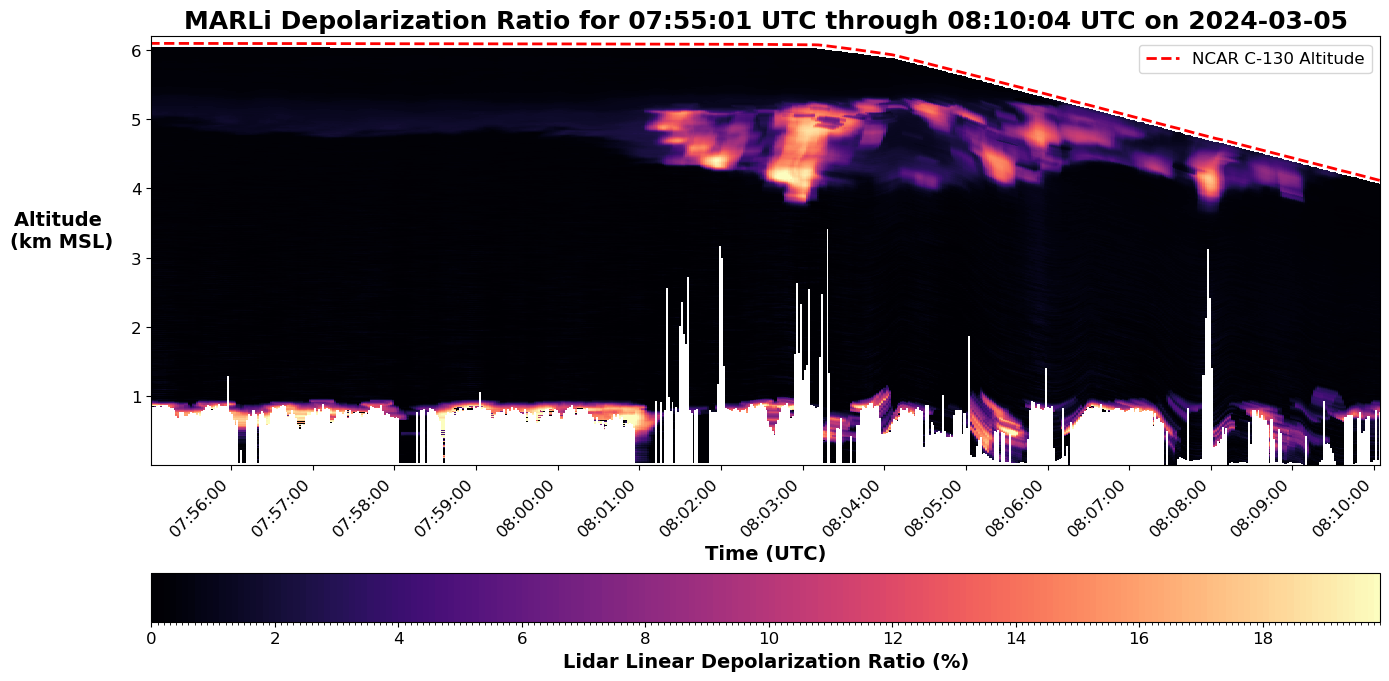

In [33]:
# set fontsize label sizes
fontsize_labels, fontsize_title, tick_sizes = 14, 18, 12
tinterval = 1 # xlabel interval
xmin, xmax = time_dt[4040], time_dt[4675] # for 7:55 through 08:10 time_dt[4040], time_dt[4675] # use 0 and -1 for full profile # 870 to 1846 for 06:40-07:03
t_start, t_end = str(xmin)[11:19], str(xmax)[11:19]

# create figure
fig, ax = plt.subplots(figsize=(14,7))
# set levels to plot data based on a vmin, vmax, and interval
levels = np.arange(vmin, vmax, interval)
norm = mcolors.BoundaryNorm(levels, ncolors=256) # normalize levels to use in pcolormesh colormap
# plot by pcolormesh curtain
mesh = ax.pcolormesh(
    time_dt,
    height,
    voi,
    shading="auto", norm=norm, cmap=cmap_choice
)
# set colorbar specifications
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.17, aspect=25)
cbar.set_label(cbar_label, fontsize=fontsize_labels, fontweight='bold')
cbar.ax.tick_params(labelsize=tick_sizes)
ax.set_xlabel('Time (UTC)', fontsize=fontsize_labels, fontweight='bold')
ax.set_ylabel('Altitude \n(km MSL)', fontsize=fontsize_labels, fontweight='bold',rotation=0, labelpad=50) # height above sea level, hence 'km (MSL)'
ax.set_title(f'MARLi {title} for {t_start} UTC through {t_end} UTC on {date}', fontsize=fontsize_title, fontweight ='bold')

# plot flight track
ax.plot(time_dt, alt, color=planecolor, linestyle='--', linewidth=2, label='NCAR C-130 Altitude')

# set xaxis range and labels
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=tinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='both',labelsize=tick_sizes)
ax.legend(loc='upper right', fontsize=tick_sizes)
plt.tight_layout()
if savefig == True:
    plt.savefig(f'{savepath}MARLi_RF{rf}_{var_choice}_{t_start}--{t_end}.png', dpi=300, bbox_inches='tight')
else:
    plt.show()